In [2]:
# import codes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')


In [10]:
#Read data 
df = pd.read_csv(r"C:\Users\sawye\Downloads\DataScience(1)\DATASET\nascar_driver_statistics.csv")
df.head()


,Unnamed: 0,Driver,Wins,AvgStart,AvgMidRace,AvgFinish,AvgPos,PassDiff,GreenFlagPasses,GreenFlagPassed,...,PercentQualityPasses,NumFastestLaps,LapsInTop15,PercentLapsInTop15,LapsLed,PercentLapsLed,TotalLaps,DriverRating,Points,Year
0,1,Joey Logano,2,10.9,13.5,13.9,11.9,175,2950,2775,...,58.7,214,5746,75.1,538,7.0,7647,89.5,3071,2022
1,2,Ross Chastain,2,14.6,13.2,14.2,12.4,94,2793,2699,...,57.9,388,5691,76.7,585,7.9,7415,92.8,3059,2022
2,3,Kyle Larson,2,8.0,14.4,13.6,12.6,268,2774,2506,...,61.0,376,5806,79.7,360,4.9,7282,91.8,3057,2022
3,4,Ryan Blaney,0,10.5,11.4,13.8,12.1,215,2686,2471,...,62.4,259,5571,76.8,457,6.3,7252,91.5,3056,2022
4,5,Denny Hamlin,2,12.2,16.5,16.1,13.8,383,3144,2761,...,59.0,338,5306,72.4,392,5.3,7332,87.9,3049,2022


Formulate research question 

- What factors predict driver rating?

In [11]:
#Sort by Driver Rating (highest to lowest) (Cleaning)
df_sorted = df.sort_values(by="DriverRating", ascending=False)
df_sorted

,Unnamed: 0,Driver,Wins,AvgStart,AvgMidRace,AvgFinish,AvgPos,PassDiff,GreenFlagPasses,GreenFlagPassed,...,PercentQualityPasses,NumFastestLaps,LapsInTop15,PercentLapsInTop15,LapsLed,PercentLapsLed,TotalLaps,DriverRating,Points,Year
448,449,Kevin Harvick,3,8.4,5.3,8.7,7.2,426,3171,2745,...,65.7,1380,9510,93.4,2294,22.5,10180,118.9,5042,2015
319,320,Martin Truex Jr.,8,6.8,8.0,9.4,7.2,150,2841,2691,...,63.4,1338,9478,91.4,2253,21.7,10368,116.1,5040,2017
248,249,Kevin Harvick,8,8.8,7.9,8.8,8.1,218,2159,1941,...,68.7,1295,8759,90.4,1990,20.5,9691,115.5,5034,2018
60,61,Kyle Larson,10,6.1,10.3,9.1,8.6,389,2643,2254,...,60.2,1288,7677,85.3,2581,28.7,9000,112.4,5040,2021
904,905,Jimmie Johnson,7,8.3,9.2,11.1,8.7,260,2299,2039,...,72.6,1299,8768,85.1,2238,21.7,10298,112.2,6652,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,166,Stanton Barrett,0,34.0,39.0,38.0,38.9,0,2,2,...,0.0,0,0,0.0,0,0.0,49,24.3,1,2020
119,120,Matt Mills,0,39.0,38.0,38.0,38.3,2,5,3,...,0.0,0,0,0.0,0,0.0,255,24.2,0,2021
383,384,Mark Thompson,0,36.0,39.0,39.0,36.7,1,16,15,...,0.0,0,0,0.0,0,0.0,25,23.7,0,2017
294,295,Stanton Barrett,0,39.0,40.0,40.0,39.1,0,3,3,...,0.0,0,0,0.0,0,0.0,11,23.3,1,2018


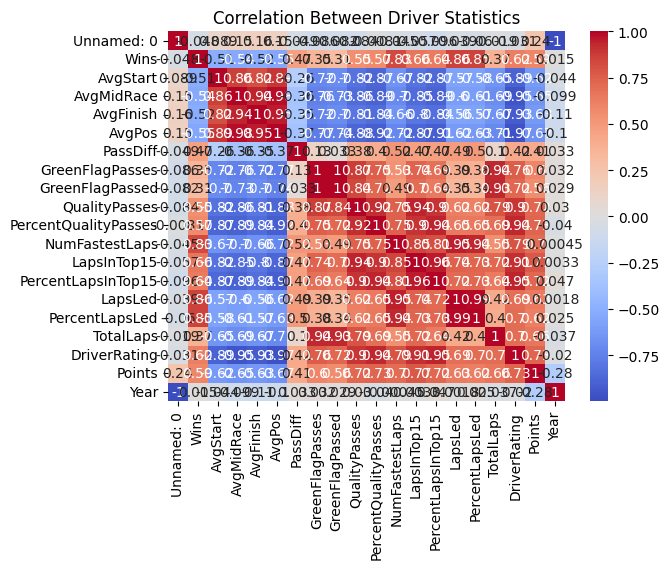

In [12]:
# Heatmap: Driver Rating vs. Average Start Position
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Driver Statistics")
plt.show()


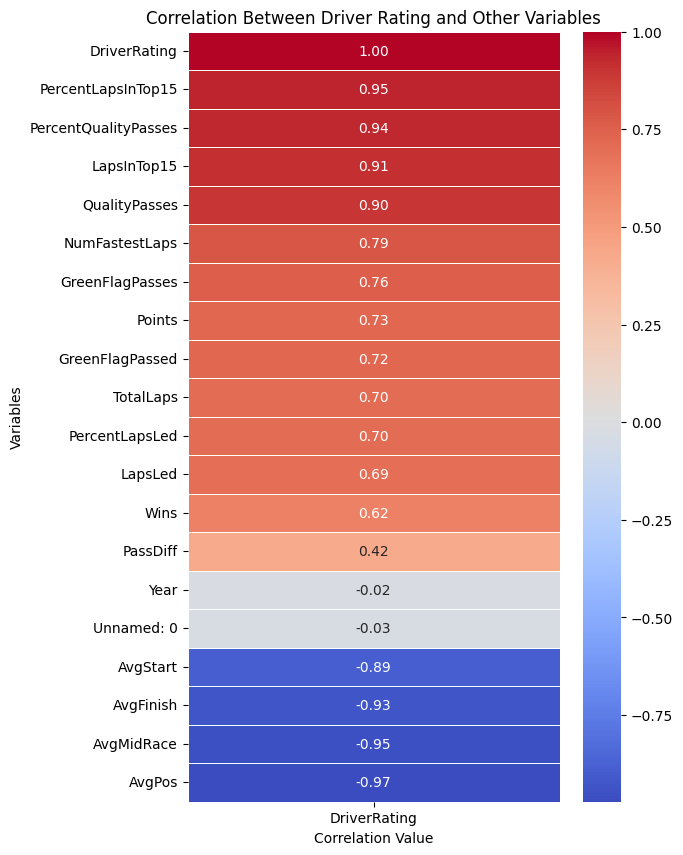

In [ ]:
#Heatmap: Driver Rating vs. Other Variables
numeric_df = df.select_dtypes(include="number")

# Compute correlations with driver_rating
corr = numeric_df.corr()[["DriverRating"]].sort_values(
    by="DriverRating", ascending=False)

# Plot heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5)

plt.title("Correlation Between Driver Rating and Other Variables")
plt.ylabel("Variables")
plt.xlabel("Correlation Value")
plt.show()

Top leading correlations with Driver Rating
- Percent Laps in Top 15
- Percent Quality Passes
- Laps inside top 15 
- Quality passes

Something to take away from the top correlations is that they specfically focus on how often your inside the top 15 and the quality of passes you perform

Disect information and come up with a more indepth question

What causes the variable "Percent Laps in Top 15" to be so influential when it comes to deciding Driver rating?

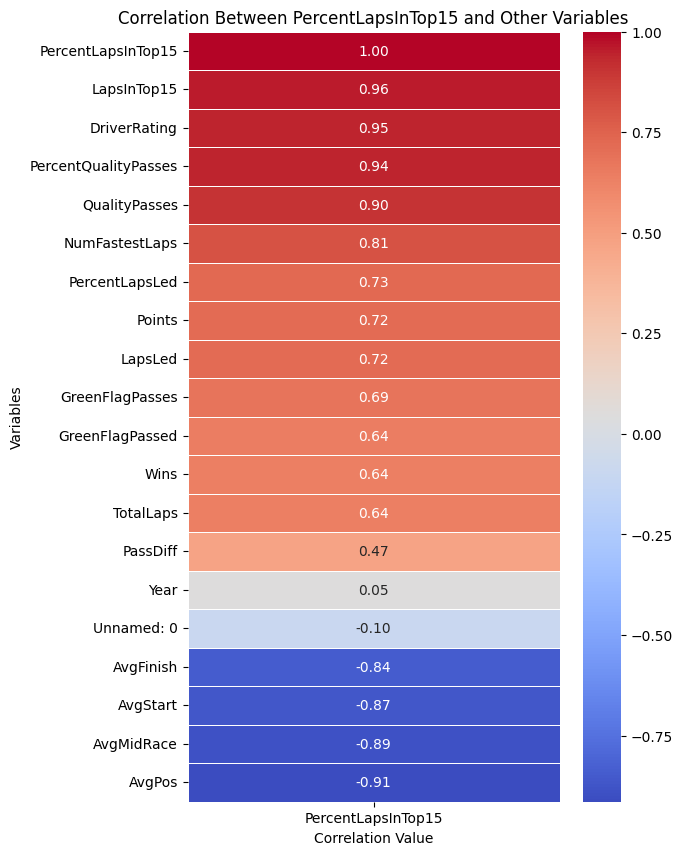

In [22]:
#Heatmap: PercentLapsInTop15 vs. Other Variables
numeric_df = df.select_dtypes(include="number")

# Compute correlations with PercentLapsInTop15
corr = numeric_df.corr()[["PercentLapsInTop15"]].sort_values(
    by="PercentLapsInTop15", ascending=False)

# Plot heatmap
plt.figure(figsize=(6, 10))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5)

plt.title("Correlation Between PercentLapsInTop15 and Other Variables")
plt.ylabel("Variables")
plt.xlabel("Correlation Value")
plt.show()

The code below is a simple linear regression manually to see how PercentLapsInTop15 predicts DriverRating. 
I then use a scatter plot to show the results

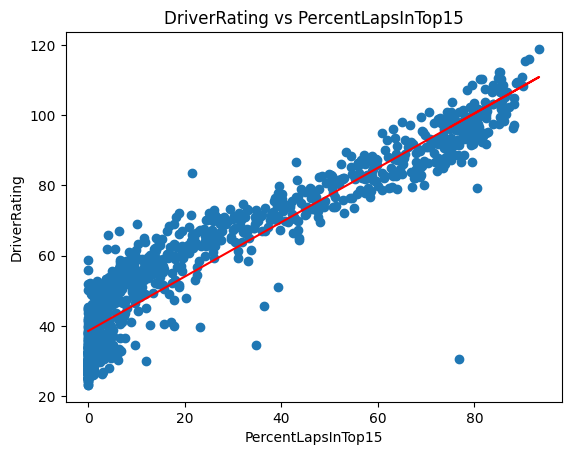

In [23]:

import numpy as np

x = df["PercentLapsInTop15"].values
y = df["DriverRating"].values

# Remove missing values
mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# Compute slope and intercept manually
slope = np.cov(x, y, bias=True)[0, 1] / np.var(x)
intercept = y.mean() - slope * x.mean()

slope, intercept

import matplotlib.pyplot as plt

plt.scatter(x, y)
plt.plot(x, slope * x + intercept, color="red")
plt.xlabel("PercentLapsInTop15")
plt.ylabel("DriverRating")
plt.title("DriverRating vs PercentLapsInTop15")
plt.show()

